# 1. Importing Needed libaries

Run the following cell to import the necessary Libraries for running the pipeline

In [7]:
from boltz_predictor import *
from boltz2_process_batch import *
#from boltz_pipeline import *
from itertools import repeat
import os
import sys
import subprocess
import json
import tempfile
import yaml
import shutil
from pathlib import Path
import time
from datetime import datetime
from typing import Dict, List, Tuple, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import py3Dmol
from IPython.display import display, HTML
import torch
import ipywidgets as widgets
from matplotlib.colors import LinearSegmentedColormap
from ipywidgets import Layout
import io
from IPython.display import display, Image

# 2. Loading Data in .csv format

Run the following  cell and press the buttons to upload your enzyme and substrate .csv
For the pipeline to run smoothly keep in mind the following format:
1. For the .csv of enzymes
* you should have a column with the enzyme_id named 'homolog'
* The sequence column should be named aa_sequence

2. For the .csv of substrates
* you should have a column with substrate id named substrate
* The substrate should be in SMILE notation and the column name should be called 'SMILES_charged'

In [2]:
# --- Create File Upload Widgets ---
enzyme_uploader = widgets.FileUpload(
    accept='.csv',
    description='Upload Enzymes CSV'
)
substrate_uploader = widgets.FileUpload(
    accept='.csv',
    description='Upload Substrates CSV'
)

# --- Display the upload buttons ---
print("Please upload your enzyme and substrate files:")
display(enzyme_uploader, substrate_uploader)


Please upload your enzyme and substrate files:


FileUpload(value=(), accept='.csv', description='Upload Enzymes CSV')

FileUpload(value=(), accept='.csv', description='Upload Substrates CSV')

# 3. Setting up the pipeline run

Run the following chunk to configure your run and predictions. The Dry-run option allows you to get a sneak-peek of which experiments will be ran by the pipeline before actually running the Boltz-2 inference. 

In [ ]:

# --- Define Interactive Widgets for Configuration ---
# These are defined globally in this cell so the next cell can access them
style = {'description_width': 'initial'}
layout = Layout(width='80%')
output_dir_widget = widgets.Text(value='boltz_batch_output', description='Output Directory:', style=style, layout=layout)
run_name_widget = widgets.Text(value='run_01', description='Run Name:', style=style, layout=layout)
cofactor_smiles_widget = widgets.Textarea(value='C[S+](CC[C@H](C(=O)[O-])N)C[C@@H]1[C@H]([C@H]([C@@H](O1)N2C=NC3=C(N=CN=C32)N)O)O', description='Cofactor SMILES:', style=style, layout=layout)
second_cofactor_smiles_widget = widgets.Text(value='[Zn+2]', description='Second Cofactor SMILES:', style=style, layout=layout)
dry_run_widget = widgets.Checkbox(value=False, description='Perform Dry Run', style=style)
num_jobs_widget = widgets.IntText(value=0, description='Number of Jobs to Run:', style=style, layout=layout) # Placeholder value
run_button = widgets.Button(description="Run Pipeline", button_style='success')
output_widget = widgets.Output()

# --- A wrapper to keep the main logic clean ---
def setup_and_run_pipeline():
    try:
        # --- Process Enzyme Data ---
        enzyme_input_dict = enzyme_uploader.value[0]
        enzyme_filename = enzyme_input_dict['name']
        enzyme_content = enzyme_input_dict['content']
        enzymes_df = pd.read_csv(io.BytesIO(enzyme_content))
        print(f"Successfully loaded {len(enzymes_df)} enzymes from '{enzyme_filename}'.")

        # --- Process Substrate Data ---
        substrate_input_dict = substrate_uploader.value[0]
        substrate_filename = substrate_input_dict['name']
        substrate_content = substrate_input_dict['content']
        substrates_df = pd.read_csv(io.BytesIO(substrate_content))
        print(f"Successfully loaded {len(substrates_df)} substrates from '{substrate_filename}'.")

        # --- Display loaded data ---
        print("\n--- Enzymes to be Processed ---")
        display(enzymes_df.head())
        print("\n--- Substrates to be Processed ---")
        display(substrates_df.head())

        # --- Create the full combinatorial dataset ---
        temp_predictor = BOLTZPredictor(output_dir='boltz_batch_output')
        combinatorial_df = temp_predictor.create_dataset(enzymes_df, substrates_df)
        print("\n--- Full Job List ---")
        display(combinatorial_df.head())

        # --- Update the num_jobs_widget with the correct max value ---
        num_jobs_widget.value = len(combinatorial_df)
        num_jobs_widget.description = f'Number of Jobs to Run (Max: {len(combinatorial_df)}):'

        def run_pipeline_on_click(b):
            with output_widget:
                output_widget.clear_output()
                print("--- Starting Pipeline ---")
                output_directory = output_dir_widget.value
                run_name = run_name_widget.value
                cofactor_smiles = cofactor_smiles_widget.value
                second_cofactor_smiles = second_cofactor_smiles_widget.value
                dry_run = dry_run_widget.value
                num_jobs = num_jobs_widget.value
                predictor = BOLTZPredictor(output_dir=output_directory)
                jobs_to_run_df = combinatorial_df.head(num_jobs)
                print(f"Preparing to run {len(jobs_to_run_df)} jobs...")
                job_list_path = predictor.output_dir / f"{run_name}_job_list.csv"
                jobs_to_run_df.to_csv(job_list_path, index=False)
                print(f"Job list for this run saved to {job_list_path}")
                # --- Call the process_batch_predictions method from the predictor instance ---
                predictor.process_batch_predictions(
                    input_df=jobs_to_run_df, file_name_stem=run_name,
                    cofactor_smiles=cofactor_smiles, second_cofactor_smiles=second_cofactor_smiles, dry_run=dry_run
                )
                print("\n--- ✅ Pipeline Finished ---")
                print("You can now proceed to the next step to view and download results.")

        run_button.on_click(run_pipeline_on_click)
        print("\n--- ⚙️ Configure Your Run ---")
        display(output_dir_widget, run_name_widget, cofactor_smiles_widget, second_cofactor_smiles_widget, dry_run_widget, num_jobs_widget, run_button, output_widget)

    except (IndexError, TypeError):
        print("\n⚠️ Please upload both the enzyme and substrate files in the cell above before running this cell.")

# --- Run the setup function ---
setup_and_run_pipeline()

Successfully loaded 14 enzymes from 'homolog_aaseq.csv'.
Successfully loaded 14 substrates from 'substrate_SMILES.csv'.

--- Enzymes to be Processed ---


,homolog,aasequence
0,E1,MATHDIAAQHLADGIAASGPAPDLAAAAAFLEMGDRLGVVAHLDPD...
1,E2,MQNVDRGITGSSLAGSAILLEIGAEYGIIETLQNSPVLDAATVSRS...
2,E3,MQNVDRGITGSSLAGSAILLEIGAEYGVIDFLQKSPIVDAAAASRS...
3,E4,MTEVMSASAMDSAQNLAGKSIFLEMGARLGVVDLLMQGDPFDAERV...
4,E5,MTGDDVQGQLAELRRSHPELHALADPRRIAAWEAARGSAPGRHDDF...



--- Substrates to be Processed ---


,substrate,SMILES_charged
0,S1,O=C([O-])C([O-])=O
1,S2,CC(C(=O)[O-])O
2,S3,C(C(=O)[O-])O
3,S4,C(C(=O)[O-])C(=O)[O-]
4,S5,C(CO)C(=O)[O-]


   Job_num enzyme_id                                   Protein_sequence  \
0        1        E1  MATHDIAAQHLADGIAASGPAPDLAAAAAFLEMGDRLGVVAHLDPD...   

  substrate_id              SMILES  
0           S1  O=C([O-])C([O-])=O  
Generated 196 unique enzyme-substrate combinations.

--- Full Job List ---


...

Text(value='[Zn+2]', description='Second Cofactor SMILES:', layout=Layout(width='80%'), style=TextStyle(descri…

Checkbox(value=False, description='Perform Dry Run', style=CheckboxStyle(description_width='initial'))

IntText(value=196, description='Number of Jobs to Run (Max: 196):', layout=Layout(width='80%'), style=Descript…

Button(button_style='success', description='Run Pipeline', style=ButtonStyle())

Output()

## 4 View, Filter, and Download Results

After the pipeline finishes, this cell displays the full results and plots. You can then use the slider to set an affinity threshold and create a zip file containing the plots and only the filtered structures.

--- 📊 Full Prediction Results ---


,Job_num,enzyme_id,substrate_id,run_type,SMILES,confidence_score,ptm,iptm,plddt,boltz_affinity_value,log_ic50_uM,ic50_uM,ic50_nM,pic50,kd_uM,kd_nM,pkd,delta_g_kcal,affinity_prob
0,1-A,E1,NaN,cofactor_only,NaN,0.961670,0.933950,0.982172,0.956545,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1-B,E1,S1,cofactor_and_substrate,O=C([O-])C([O-])=O,0.975780,0.962219,0.984260,0.973659,0.930496,0.930496,8.521099,8521.099171,5.069504,4.260550,4260.549585,5.370534,6.914804,0.766778
2,2-A,E1,NaN,cofactor_only,NaN,0.952856,0.937974,0.960629,0.950913,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2-B,E1,S2,cofactor_and_substrate,CC(C(=O)[O-])O,0.975229,0.965792,0.989290,0.971714,2.020951,2.020951,104.942295,104942.294560,3.979049,52.471147,52471.147280,4.280079,5.427423,0.655627
4,3-A,E1,NaN,cofactor_only,NaN,0.963059,0.939104,0.983999,0.957824,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,3-B,E1,S3,cofactor_and_substrate,C(C(=O)[O-])O,0.976889,0.966776,0.987255,0.974298,1.540457,1.540457,34.710153,34710.153433,4.459543,17.355077,17355.076716,4.760573,6.082817,0.740715
6,4-A,E1,NaN,cofactor_only,NaN,0.961416,0.933228,0.981895,0.956297,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,4-B,E1,S4,cofactor_and_substrate,C(C(=O)[O-])C(=O)[O-],0.975347,0.955726,0.980312,0.974106,2.616222,2.616222,413.258378,413258.377560,3.383778,206.629189,206629.188780,3.684808,4.615474,0.551263



--- 📈 Result Plots ---

Generating affinity distribution bar plot...
  Bar plot saved to: interactive_test_03/run_01_affinity_barplot.pdf

Generating enzyme-substrate affinity heatmap...


/home/developer/Projects/cofolding_project/boltz_predictor.py:420: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  heatmap_data = plot_df.pivot_table(index='enzyme_id', columns='substrate_id', values='affinity_prob')


  Heatmap saved to: interactive_test_03/run_01_affinity_heatmap.png

Enzyme-Substrate Affinity Heatmap:


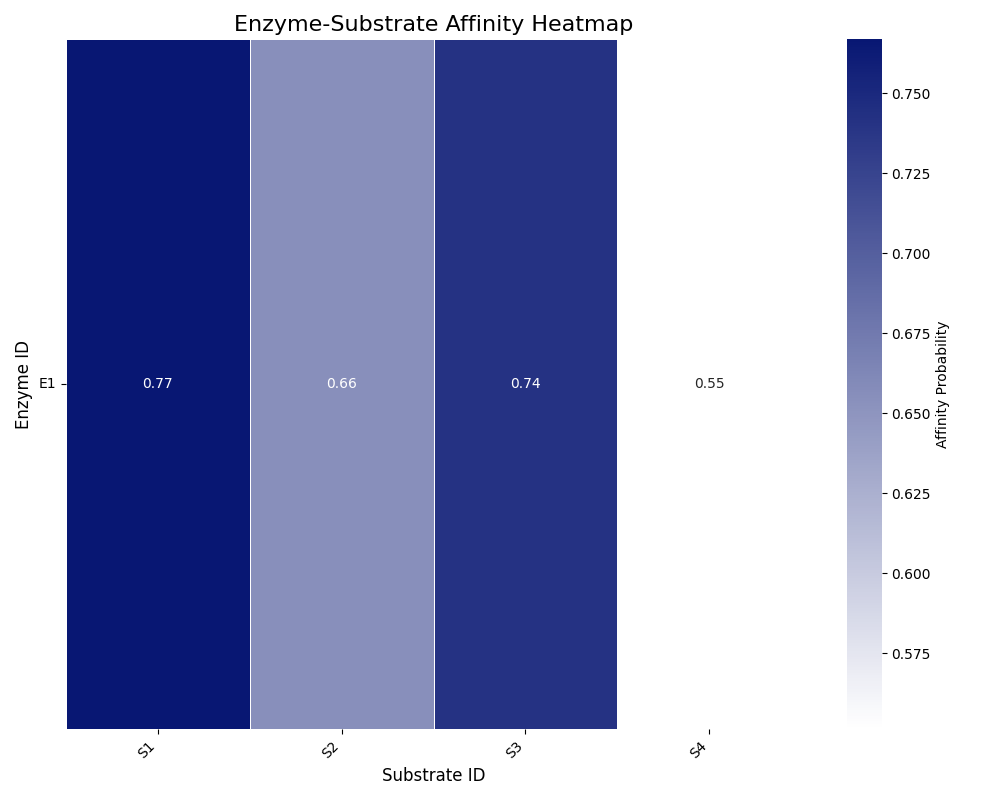


--- 🔬 3D Structure Visualization (Sample) ---
Displaying structure: E1_S1.cif


3Dmol.js failed to load for some reason. Please check your browser console for error messages.



--- 🔬 Filter and Create High-Affinity Zip ---


FloatSlider(value=0.75, description='Min Affinity Probability:', layout=Layout(width='80%'), max=1.0, step=0.0…

Button(button_style='primary', description='Create Filtered Zip', style=ButtonStyle())

Output()

In [ ]:

# @title ## 5. View, Filter, and Download Results
#
# After the pipeline finishes, this cell displays the full results and plots.
# You can then use the slider to set an affinity threshold and create a
# zip file containing the plots and only the filtered structures.
#
# **Note:** You must re-run this cell after each pipeline run to see the latest results.
import ipywidgets as widgets
from ipywidgets import Layout

# --- Get run name and output directory from the widgets above ---
# Ensure this cell is run after the configuration cell
try:
    run_name = run_name_widget.value
    output_directory = output_dir_widget.value
except NameError:
    print("⚠️ Please run the 'Configure and Run the Pipeline' cell first.")
    # You might want to exit the cell or set default values here
    run_name = 'run_01'
    output_directory = 'boltz_batch_output'


results_zip_path = Path(output_directory) / f"{run_name}_results_and_cifs.zip"
results_csv_path = f"{run_name}_results.csv"
barplot_path = Path(output_directory) / f"{run_name}_affinity_barplot.png"
heatmap_path = Path(output_directory) / f"{run_name}_affinity_heatmap.png"

# --- Create Interactive Widgets for Filtering ---
style = {'description_width': 'initial'}
layout = Layout(width='80%')

threshold_slider = widgets.FloatSlider(
    value=0.75, min=0.0, max=1.0, step=0.01,
    description='Min Affinity Probability:',
    style=style, layout=layout, readout_format='.2f'
)
filter_button = widgets.Button(description="Create Filtered Zip", button_style='primary')
filter_output_widget = widgets.Output()

# --- Main display and filtering logic ---
if results_zip_path.exists():
    # --- 1. Display Full Results First ---
    print("--- 📊 Full Prediction Results ---")
    with zipfile.ZipFile(results_zip_path, 'r') as z:
        with z.open(results_csv_path) as f:
            results_df = pd.read_csv(f)
            display(results_df)

    # --- 2. Generate and Display Plots ---
    print("\n--- 📈 Result Plots ---")
    predictor = BOLTZPredictor(output_dir=output_directory)
    predictor.plot_results(results_df, run_name)
    if barplot_path.exists():
        print("\nAffinity Distribution:")
        display(Image(filename=str(barplot_path)))
    if heatmap_path.exists():
        print("\nEnzyme-Substrate Affinity Heatmap:")
        display(Image(filename=str(heatmap_path)))

    # --- 3. Visualize a 3D structure sample ---
    print("\n--- 🔬 3D Structure Visualization (Sample) ---")
    with zipfile.ZipFile(results_zip_path, 'r') as z:
        cif_file_name = next((name for name in z.namelist() if name.endswith('.cif')), None)
        if cif_file_name:
            print(f"Displaying structure: {cif_file_name}")
            cif_data = z.read(cif_file_name).decode('utf-8')
            view = py3Dmol.view(width=800, height=600)
            view.addModel(cif_data, 'cif')
            view.setStyle({'cartoon': {'color': 'spectrum'}})
            view.setStyle({'chain':['B','C','D']},{'stick':{}})
            view.zoomTo()
            view.show()
        else:
            print("No .cif files found in the results archive for visualization.")

    # --- 4. Interactive Filtering and Zipping ---
    def filter_and_zip_on_click(b):
        with filter_output_widget:
            filter_output_widget.clear_output()
            threshold = threshold_slider.value
            print(f"Filtering results with affinity probability >= {threshold:.2f}...")

            # Filter the dataframe
            filtered_df = results_df[results_df['affinity_prob'] >= threshold].copy()
            filtered_df = filtered_df[filtered_df['run_type'] == 'cofactor_and_substrate']

            if filtered_df.empty:
                print("No structures met the specified affinity threshold.")
                return

            print(f"Found {len(filtered_df)} structures meeting the threshold.")
            display(filtered_df)

            # Create the new zip file
            cif_files_to_keep = [f"{row.enzyme_id}_{row.substrate_id}.cif" for row in filtered_df.itertuples()]
            filtered_zip_name = f"{run_name}_filtered_affinity_{threshold:.2f}.zip"
            filtered_zip_path = Path(output_directory) / filtered_zip_name

            with zipfile.ZipFile(filtered_zip_path, 'w') as filtered_zip:
                # Add the filtered CSV
                filtered_csv_data = filtered_df.to_csv(index=False)
                filtered_zip.writestr(f"{run_name}_filtered_results.csv", filtered_csv_data)

                # Add the plots
                if barplot_path.exists():
                    filtered_zip.write(barplot_path, arcname=barplot_path.name)
                if heatmap_path.exists():
                    filtered_zip.write(heatmap_path, arcname=heatmap_path.name)

                # Copy the relevant CIF files from the original zip
                with zipfile.ZipFile(results_zip_path, 'r') as original_zip:
                    for item in original_zip.infolist():
                        if item.filename in cif_files_to_keep:
                            filtered_zip.writestr(item.filename, original_zip.read(item.filename))

            print(f"\nCreated filtered zip file: '{filtered_zip_name}'")
            # Create a relative path for the link, which is more robust
            try:
                relative_path = filtered_zip_path.relative_to(Path.cwd())
            except ValueError:
                relative_path = filtered_zip_path.resolve()

            # Display a clickable HTML link for downloading
            display(HTML(f'✅ Your file is ready. <a href="{relative_path}" target="_blank">Click here to download {filtered_zip_name}</a>'))
            print(f"If the link doesn't work, you can find your file at: {filtered_zip_path.resolve()}")


    # Link function to button and display
    filter_button.on_click(filter_and_zip_on_click)
    print("\n\n--- 🔬 Filter and Create High-Affinity Zip ---")
    display(threshold_slider, filter_button, filter_output_widget)

else:
    print(f"Could not find the results zip file at '{results_zip_path}'.")
    print("Please ensure the pipeline has run successfully and the 'Run Name' and 'Output Directory' match.")
